# How well do two classical transition-detection methods agree with the unsupervised consensus?

This notebook produces two of the five transition-detection panels compared in
Appendix E: `Plots/Fig_E1.pdf` (learning by confusion) and `Plots/Fig_E2.pdf`
(the prediction-divergence method). The other three comparison methods, PCA/UMAP
clustering and distance learning, are produced by separate notebooks.

### The question

Before TetrisCNN can be trained as a supervised classifier, the experimental sweep
needs supervised labels, which first requires locating the transition itself from
unlabeled data. Learning by confusion (LBC) and the prediction-divergence method (PDM)
are two classical ways to do that, and this notebook checks that TetrisCNN, used as
the backbone for each, agrees with the more direct clustering-based estimate.

LBC turns the problem into many ordinary classification problems: for each candidate
split time, snapshots below and above it are relabeled into two classes and a fresh
classifier is trained to distinguish them, and the split with the highest accuracy is
the transition estimate. PDM instead trains a single regressor once, over the whole
sweep, and reads every candidate boundary from that one fit: it locates the split
where the model's snapshot-averaged prediction changes fastest with the true tuning
parameter. Despite the different mechanics, both are proxies for the same underlying
susceptibility of the snapshot distribution, so their agreement with each other, and
with the clustering-based estimate of the companion notebook, is what makes the
detected transition trustworthy rather than an artifact of one particular method.

This notebook does not re-derive why the detected Ising transition corresponds to the
loss of the initial $Z$-polarization rather than to the later antiferromagnetic phase
transition; that discussion belongs to the main text and is only referenced here.

### What it reads

Two kinds of saved runs under `Plots_data/App_E_data/models/`. The PDM panel needs actual
inference: `Ising_PDM` and `XY_XZ_PDM` are trained regression runs (`config.json`,
`metrics.json`, `net1.pt`, `net2.pt`), pushed back through the network below to get
snapshot-averaged predictions across the sweep. The LBC panel only needs recorded
configuration: `Ising_CLF` and `XY_XZ_CLF` supply the partition boundaries
(`cf.unique_labels`) of the classification sweep, while the actual per-partition
accuracy curves come pre-aggregated from `Plots_data/App_E_data/lbc_metrics/{Ising,XY}.pkl`, one
pickle per dataset holding five random seeds' worth of train/validation accuracy at a
representative $\lambda_{\max}$.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE
from tetriscnn.models import ShapeAdaptiveConvNet, SmallModel
from tetriscnn.utils import (
    AttrDict, load_json, build_sr_folder_path, pick_directory, DEVICE, kernel_to_latex_pattern
)
from tetriscnn.datasets import create_datasets

from tetriscnn.colors import COLORS, colors

from pathlib import Path
import pickle
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy.optimize import minimize_scalar, brentq
import seaborn as sns

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec

plt.style.use(PAPER_MPLSTYLE)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
golden_ratio = (1 + np.sqrt(5)) / 2

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Loading a recorded run

The same three loaders recur across these figure notebooks. `_load_config_from_folder`
restores a run's `config.json` into the training code's own `AttrDict`, padding any
kernel specification recorded before the stride became a required fifth element.
`_load_metrics_from_folder` reads the per-epoch `metrics.json` history.
`_load_model_and_datasets` additionally reconstructs the trained Net1/Net2 pair and
its validation split; the PDM runs below use this to compute fresh predictions, while
the classification runs loaded for the LBC panel only ever need the configuration
this call also returns, since the LBC sweep results themselves are read back from a
separate pickle.


In [2]:
def _load_config_from_folder(seed_folder: Path) -> AttrDict:
    cfg_path = seed_folder / "config.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"No config.json found in {seed_folder}")
    cf = AttrDict()
    cf.update(load_json(str(seed_folder), "config.json"))
    for k in range(len(cf.kernels)):          # stride compatibility fix
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)
    cf.logdir = str(seed_folder)
    return cf

In [3]:
def _load_metrics_from_folder(seed_folder: Path) -> dict:
    cfg_path = seed_folder / "metrics.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"No metrics.json found in {seed_folder}")
    return load_json(str(seed_folder), "metrics.json")

In [4]:
def _load_model_and_datasets(cf, load_path):
    cf.logdir = str(load_path)
    cf.seed_folder = str(load_path)
    cf.return_all_data = False
    train_dataset, val_dataset = create_datasets(cf)

    in_channels = train_dataset[0][0].shape[0]
    net2_dims   = [len(cf.kernels), 32, 16, train_dataset.output_dim]

    net1 = ShapeAdaptiveConvNet(
        in_channels=in_channels, kernels=cf.kernels, equivariant=cf.equivariant,
        hidden_size=cf.hidden_size, init=cf.init, device=DEVICE
    ).to(DEVICE)
    net2 = SmallModel(net2_dims, device=DEVICE).to(DEVICE)

    try:
        net1.load_state_dict(torch.load(load_path / "net1.pt", map_location=DEVICE))
        net2.load_state_dict(torch.load(load_path / "net2.pt", map_location=DEVICE))
    except FileNotFoundError:
        print(f"[ERROR] Model weights not found in {load_path}.")

    net1.eval(); net2.eval()
    return net1, net2, val_dataset

## Ising

Two runs are loaded for the Ising dataset: the prediction-divergence regressor
directly below, and, further down, the classification run whose recorded partition
grid supplies the time axis for the LBC panel. The regressor's output has two
channels, index 0 for the longitudinal detuning $\delta$ and index 1 for the
transverse coupling $\Omega$; only the $\delta$ channel is used here, per Appendix E,
since $\Omega$'s dynamics are set mostly by $X$-basis statistics that the $Z$-basis
snapshots see only weakly.


In [5]:
basepath = Path("Plots_data/App_E_data/models/Ising_PDM")

cf_Ising = _load_config_from_folder(basepath)
net1, net2, val_dataset = _load_model_and_datasets(cf_Ising, basepath)
metrics_Ising = _load_metrics_from_folder(basepath)


[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples
times shape: 14613, labels shape: torch.Size([14613, 2])


times shape: 6282, labels shape: torch.Size([6282, 2])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.


In [6]:
val_loader = DataLoader(
    val_dataset, batch_size=len(val_dataset),
    shuffle=False, num_workers=0, pin_memory=False
)

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE).view(-1, val_loader.dataset[0][1].shape[0])
        z   = net1(x)
        out = net2(z)

z_Ising   = z.cpu()
out_Ising = out.cpu()

In [7]:
bottlenecks_mu_Ising, bottlenecks_sigma_Ising = [], []
for k in range(len(cf_Ising.kernels)):
    mu_k, sig_k = val_dataset.snapshot_average(z[:, k].to(DEVICE), output=False)
    bottlenecks_mu_Ising.append(mu_k)
    bottlenecks_sigma_Ising.append(sig_k)
bottlenecks_mu_Ising    = np.array(bottlenecks_mu_Ising).T
bottlenecks_sigma_Ising = np.array(bottlenecks_sigma_Ising).T

ch = 0 # If Ising: 0-delta, 1-omega

outputs_mu_Ising, outputs_sigma_Ising = val_dataset.snapshot_average(out.to(DEVICE))
outputs_mu_Ising, outputs_sigma_Ising = outputs_mu_Ising[:, ch], outputs_sigma_Ising[:, ch]

times_unique_Ising  = val_dataset.unique_times.cpu()
labels_unique_Ising = val_dataset.unique_labels_unnormalized[:, ch]

Only the configuration this run recorded is needed here, specifically
`cf_Ising_CLF.unique_labels`, the partition boundaries of the classification sweep;
it supplies the time axis for the LBC panel below.


In [8]:
basepath = Path("Plots_data/App_E_data/models/Ising_CLF")

cf_Ising_CLF = _load_config_from_folder(basepath)
net1, net2, val_dataset = _load_model_and_datasets(cf_Ising_CLF, basepath)
metrics_Ising_CLF = _load_metrics_from_folder(basepath)


 [LbC] CREATING DATASET: partition 3/27, threshold=1100.0000, total 20895 samples.

[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] LBC class distribution: class 0=2140, class 1=18755
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples
times shape: 14613, labels shape: torch.Size([14613])


times shape: 6282, labels shape: torch.Size([6282])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.


## XY

The same pattern repeats for the XY dataset: the prediction-divergence regressor
below, then, further down, the classification run's partition grid for the LBC panel.
Unlike Ising, the XY regressor already outputs the single scalar staggered detuning
$\delta^{\mathrm{stag}}$ directly, so no channel selection is needed on its
prediction.


In [9]:
# XY (6x7, X+Z) prediction-divergence (regression) run: lambda_max = -1, seed 45.
# Refreshed from logs/ with the corrected data loading -- see Plots_data/App_E_data/.
basepath = Path("Plots_data/App_E_data/models/XY_XZ_PDM")

cf_XY = _load_config_from_folder(basepath)
net1, net2, val_dataset = _load_model_and_datasets(cf_XY, basepath)
metrics_XY = _load_metrics_from_folder(basepath)


[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124, 1])
times shape: 4347, labels shape: torch.Size([4347, 1])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.


In [10]:
val_loader = DataLoader(
    val_dataset, batch_size=len(val_dataset),
    shuffle=False, num_workers=0, pin_memory=False
)

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE).view(-1, val_loader.dataset[0][1].shape[0])
        z   = net1(x)
        out = net2(z)

z_XY   = z.cpu()
out_XY = out.cpu()

In [11]:
bottlenecks_mu_XY, bottlenecks_sigma_XY = [], []
for k in range(len(cf_XY.kernels)):
    mu_k, sig_k = val_dataset.snapshot_average(z[:, k].to(DEVICE), output=False)
    bottlenecks_mu_XY.append(mu_k)
    bottlenecks_sigma_XY.append(sig_k)
bottlenecks_mu_XY    = np.array(bottlenecks_mu_XY).T
bottlenecks_sigma_XY = np.array(bottlenecks_sigma_XY).T

ch = 0 # If Ising: 0-delta, 1-omega

outputs_mu_XY, outputs_sigma_XY = val_dataset.snapshot_average(out.to(DEVICE))
outputs_mu_XY, outputs_sigma_XY = outputs_mu_XY, outputs_sigma_XY

times_unique_XY  = val_dataset.unique_times.cpu()
labels_unique_XY = val_dataset.unique_labels_unnormalized

As for Ising, only `cf_XY_CLF.unique_labels` is used from this run, supplying the
partition grid for the LBC panel below.


In [12]:
# XY (6x7, X+Z) classification (partition) run: lambda_max = -1, seed 45.
basepath = Path("Plots_data/App_E_data/models/XY_XZ_CLF")

cf_XY_CLF = _load_config_from_folder(basepath)
net1, net2, val_dataset = _load_model_and_datasets(cf_XY_CLF, basepath)
metrics_XY_CLF = _load_metrics_from_folder(basepath)


 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.


## Learning by confusion (Fig. E1)

Learning by confusion locates a transition by turning it into a family of ordinary
classification problems. For a trial split time $y'$, snapshots below and above it
are relabeled into two classes and TetrisCNN is retrained from scratch as their
classifier; sweeping $y'$ across the experimental grid traces out a confusion curve
whose interior accuracy maximum estimates the transition. The two cells below load a
pre-computed sweep for each dataset, five random seeds at a representative
$\lambda_{\max}$, and locate that maximum from the seed-averaged validation accuracy.
The manuscript's quoted uncertainty additionally folds in the spread of that maximum
across eleven swept values of $\lambda_{\max}$, which this notebook does not
recompute.

Because the experimental sweeps start close to the confusion peak rather than well
below it, only the descending half of the curve's characteristic "W" shape is
resolved. The Ising confusion peak is broad and flat as a result, visible in the
inset of panel (a) below, which is why its transition estimate carries a wider
interval, t ≈ 0.9 µs within [0.8, 1.2] µs, than the XY dataset's sharp, well-defined
peak at t ≈ 0.625 µs within [0.5, 0.75] µs.


In [13]:
with open("Plots_data/App_E_data/lbc_metrics/Ising.pkl", "rb") as f:
    summary_data_Ising_LBC_Lambdamax_forLBCplot = pickle.load(f)
seeds = list(summary_data_Ising_LBC_Lambdamax_forLBCplot.keys())
summary_data_Ising_LBC_Lambdamax_forLBCplot = {quantity: {seed: summary_data_Ising_LBC_Lambdamax_forLBCplot[seed][quantity] for seed in seeds} for quantity in summary_data_Ising_LBC_Lambdamax_forLBCplot[42].keys()}
quantities = list(summary_data_Ising_LBC_Lambdamax_forLBCplot.keys())

val_acc_arr_Ising = np.array(list(summary_data_Ising_LBC_Lambdamax_forLBCplot["val_acc"].values()))
val_acc_mean_Ising = np.mean(val_acc_arr_Ising, axis=0)
val_acc_std_Ising = np.std(val_acc_arr_Ising, axis=0)

trn_acc_arr_Ising = np.array(list(summary_data_Ising_LBC_Lambdamax_forLBCplot["train_acc"].values()))
trn_acc_mean_Ising = np.mean(trn_acc_arr_Ising, axis=0)
trn_acc_std_Ising = np.std(trn_acc_arr_Ising, axis=0)

transition_argmax_Ising = np.argmax(val_acc_mean_Ising)

partitions_Ising = (cf_Ising_CLF.unique_labels[:-1] + cf_Ising_CLF.unique_labels[1:]) / 2 / 1e3

In [14]:
with open("Plots_data/App_E_data/lbc_metrics/XY.pkl", "rb") as f:
    summary_data_XY_XZ_LBC_Lambdamax_forLBCplot = pickle.load(f)
seeds = list(summary_data_XY_XZ_LBC_Lambdamax_forLBCplot.keys())
summary_data_XY_XZ_LBC_Lambdamax_forLBCplot = {quantity: {seed: summary_data_XY_XZ_LBC_Lambdamax_forLBCplot[seed][quantity] for seed in seeds} for quantity in summary_data_XY_XZ_LBC_Lambdamax_forLBCplot[42].keys()}
quantities = list(summary_data_XY_XZ_LBC_Lambdamax_forLBCplot.keys())

val_acc_arr_XY_XZ = np.array(list(summary_data_XY_XZ_LBC_Lambdamax_forLBCplot["val_acc"].values()))
val_acc_mean_XY_XZ = np.mean(val_acc_arr_XY_XZ, axis=0)
val_acc_std_XY_XZ = np.std(val_acc_arr_XY_XZ, axis=0)

trn_acc_arr_XY_XZ = np.array(list(summary_data_XY_XZ_LBC_Lambdamax_forLBCplot["train_acc"].values()))
trn_acc_mean_XY_XZ = np.mean(trn_acc_arr_XY_XZ, axis=0)
trn_acc_std_XY_XZ = np.std(trn_acc_arr_XY_XZ, axis=0)

transition_argmax_XY_XZ = np.argmax(val_acc_mean_XY_XZ[:-1])

partitions_XY_XZ = (cf_XY_CLF.unique_labels[:-1] + cf_XY_CLF.unique_labels[1:]) / 2 / 1e3

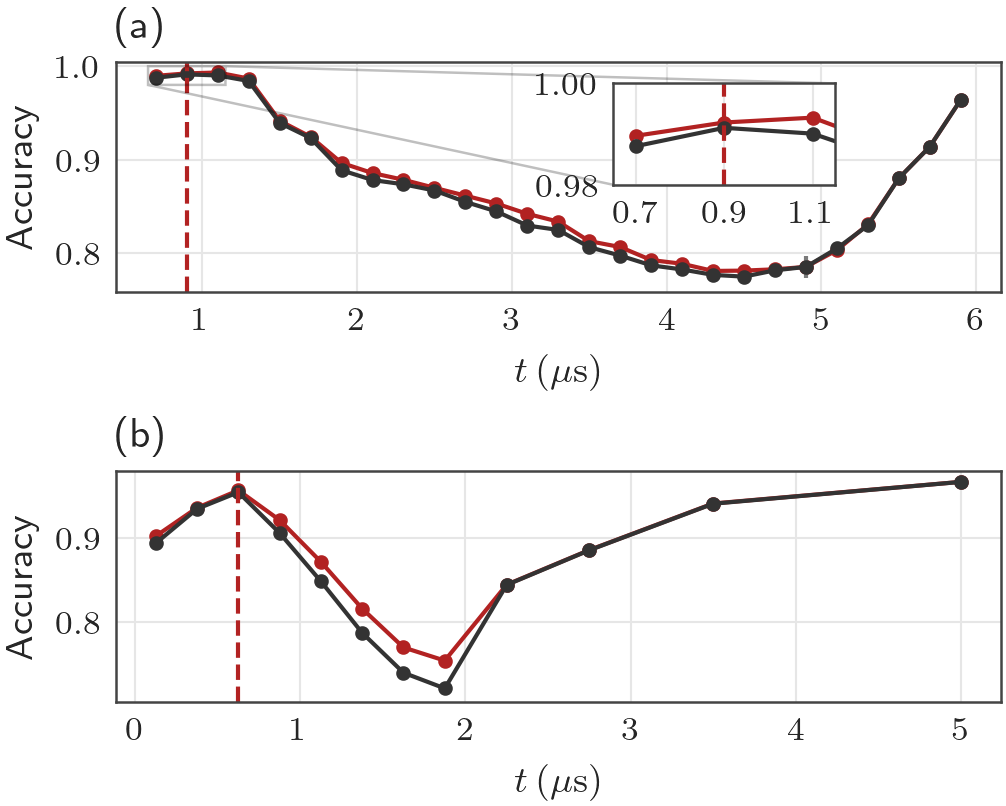

In [15]:
plt.style.use(PAPER_MPLSTYLE)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
golden_ratio = (1 + np.sqrt(5)) / 2

important_alpha = 1.0
unimportant_alpha = 0.35

# fig, axs = plt.subplot_mosaic(
#     [["A", "B", "C"], ["D", "E", "F"]],
# )

fig = plt.figure(figsize=(SINGLE_WIDTH, 1.3 * SINGLE_WIDTH / golden_ratio))

gs = gridspec.GridSpec(2, 1, figure=fig,
                       )

axs = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

ax = axs[0]

ax.errorbar(partitions_Ising, trn_acc_mean_Ising, yerr=trn_acc_std_Ising, fmt='none', color=COLORS["gray"], capsize=0)
ax.plot(partitions_Ising, trn_acc_mean_Ising, 'o-', color=COLORS["reddish"], label="Training")
ax.errorbar(partitions_Ising, val_acc_mean_Ising, yerr=val_acc_std_Ising, fmt='none', color=COLORS["gray"], capsize=0)
ax.plot(partitions_Ising, val_acc_mean_Ising, 'o-', color=COLORS["blackish"], label="Validation")
ax.axvline(partitions_Ising[transition_argmax_Ising], color=COLORS["reddish"], ls='--', label='Transition')
ax.set_xlabel(r"$t\,(\mu\mathrm{s})$")

ax_inset = inset_axes(ax, width='25%', height='44%', borderpad=1.0, bbox_to_anchor=(-0.15, 0.05, 1.0, 1.0), loc='upper right', bbox_transform=ax.transAxes)
ax_inset.errorbar(partitions_Ising, trn_acc_mean_Ising, yerr=trn_acc_std_Ising, fmt='none', color=COLORS["gray"], capsize=0)
ax_inset.plot(partitions_Ising, trn_acc_mean_Ising, 'o-', color=COLORS["reddish"], label="Training")
ax_inset.errorbar(partitions_Ising, val_acc_mean_Ising, yerr=val_acc_std_Ising, fmt='none', color=COLORS["gray"], capsize=0)
ax_inset.plot(partitions_Ising, val_acc_mean_Ising, 'o-', color=COLORS["blackish"], label="Validation")
ax_inset.axvline(partitions_Ising[transition_argmax_Ising], color=COLORS["reddish"], ls='--', label='Transition')
ax_inset.set_xlim(partitions_Ising[transition_argmax_Ising] - 0.25, partitions_Ising[transition_argmax_Ising] + 0.25)
ax_inset.set_ylim(0.98, 1.0)
ax_inset.set_xticks([partitions_Ising[transition_argmax_Ising - 1], partitions_Ising[transition_argmax_Ising], partitions_Ising[transition_argmax_Ising + 1]])
ax.indicate_inset_zoom(ax_inset, edgecolor="black", alpha=0.25)
ax.set_title("(a)", loc="left")
ax.set_ylabel("Accuracy")

ax = axs[1]

ax.errorbar(partitions_XY_XZ, trn_acc_mean_XY_XZ, yerr=trn_acc_std_XY_XZ, fmt='none', color=COLORS["gray"], capsize=0)
ax.plot(partitions_XY_XZ, trn_acc_mean_XY_XZ, 'o-', color=COLORS["reddish"], label="Training data")
ax.errorbar(partitions_XY_XZ, val_acc_mean_XY_XZ, yerr=val_acc_std_XY_XZ, fmt='none', color=COLORS["gray"], capsize=0)
ax.plot(partitions_XY_XZ, val_acc_mean_XY_XZ, 'o-', color=COLORS["blackish"], label="Validation data")
ax.axvline(partitions_XY_XZ[transition_argmax_XY_XZ], color=COLORS["reddish"], ls='--', label='Transition '+r"$y_c$")
ax.set_xlabel(r"$t\,(\mu\mathrm{s})$")
ax.set_ylabel("Accuracy")
ax.set_title("(b)", loc="left")

fig.savefig("Plots/Fig_E1.pdf")

## The prediction-divergence method (Fig. E2)

Where learning by confusion retrains a classifier per hypothesized split, the
prediction-divergence method fits a single regressor once and reads every candidate
boundary from that one fit: TetrisCNN regresses the tuning parameter directly from a
snapshot, and the transition is placed where the snapshot-averaged prediction responds
fastest to the true parameter. `_numerical_derivative_panel` implements this as a
first-order finite difference of the averaged prediction against the sorted ground
truth, so the maximum naturally falls between two neighboring acquisition times,
matching the flanking-time convention used throughout this appendix.

The trimming and search-window constants (`TRIM_LEFT`/`TRIM_RIGHT`,
`GT_SEARCH_LO`/`GT_SEARCH_HI`) exclude two artifacts unrelated to the transition
itself: a near-zero-output floor at one end of the ground-truth range, and a
sparsely-sampled, saturated tail at the other. The dashed line and shaded band in each
panel mark the resulting estimate and its full width at half maximum.

The resulting estimates, printed at the end of the cell below, are t ≈ 1.1 µs within
[1.0, 1.2] µs for Ising and t ≈ 0.625 µs within [0.5, 0.75] µs for XY, consistent with
the learning-by-confusion estimates above and with the clustering-based estimates of
the companion notebook.


True
[Ising] Trimmed points : left=0, right=22  ->  6 points remain
[Ising] GT range used  : [-7.9969, 1.8731]
[Ising] Numerical PT   : GT = -2.1655
[Ising] Numerical FWHM CI: [-3.3523, -0.9786]
0.0075471923 0.25
[XY] Trimmed points : left=6, right=0  ->  7 points remain
[XY] GT range used  : [0.2859, 15.0000]
[XY] Numerical PT   : GT = 4.1556
[XY] Numerical FWHM CI: [2.5749, 5.7363]
Ising report: GT_c = -2.17 ± 1.19
XY report   : GT_c = 4.16 ± 1.58


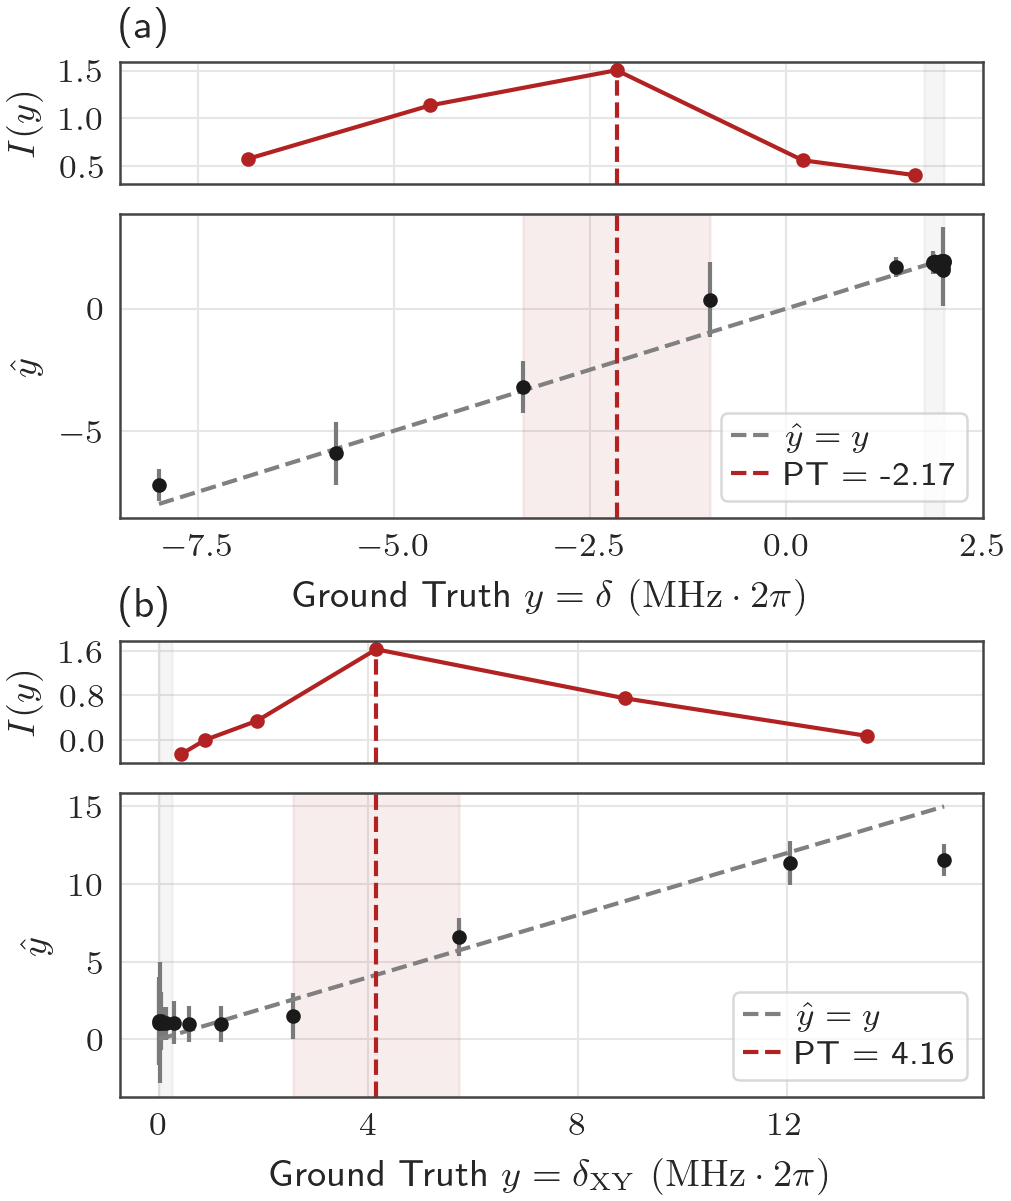

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
#  Numerical derivative comparison for Ising and XY
# ══════════════════════════════════════════════════════════════════════════════

GT_SEARCH_LO_Ising = -7.9969   # lower bound: excludes GT≈0 NN-floor artefact # Ising MODEL (Omega=0, Delta=-10)
GT_SEARCH_HI_Ising = 1.75  # upper bound: excludes sparse high-GT saturation tail # Ising MODEL (Omega=1.8, Delta=2.5)

GT_SEARCH_LO_XY = 0.25   # lower bound: excludes GT≈0 NN-floor artefact # XY MODEL
GT_SEARCH_HI_XY = 15.0  # upper bound: excludes sparse high-GT saturation tail # XY MODEL

TRIM_LEFT_Ising  = 0
TRIM_RIGHT_Ising = 22
TRIM_LEFT_XY     = 6
TRIM_RIGHT_XY    = 0
DIFF_ORDER = 1
FWHM_THRESH = 0.5
FINAL_EXCLUDED_REGION_MODE = "clip"


important_alpha = 1.0
unimportant_alpha = 0.35

# fig, axs = plt.subplot_mosaic(
#     [["A", "B", "C"], ["D", "E", "F"]],
# )

fig = plt.figure(figsize=(SINGLE_WIDTH, 2 * SINGLE_WIDTH / golden_ratio))

gs = gridspec.GridSpec(3, 1, figure=fig,
                       height_ratios=[0.225, 1, 1], 
                       )

axs = [fig.add_subplot(gs[1]), fig.add_subplot(gs[2])]

# fig.subplots_adjust(
# )

def _prepare_curve(gt, pred, sigma):
    gt = np.asarray(gt).ravel()
    pred = np.asarray(pred).ravel()
    sigma = np.asarray(sigma).ravel() if sigma is not None else np.zeros_like(gt)
    sort_idx = np.argsort(gt)
    gt = gt[sort_idx]
    pred = pred[sort_idx]
    sigma = sigma[sort_idx]
    resid_std = float(np.std(pred - np.mean(pred))) or 0.05
    sig_boot = np.where(sigma < 1e-12, resid_std, sigma)
    return gt, pred, sig_boot

def _numerical_derivative_panel(
    ax_in,
    *,
    name,
    gt,
    pred,
    sigma,
    gt_search_lo,
    gt_search_hi,
    trim_left,
    trim_right,
    x_label,
    derivative_y_label,
    numerical_color,
    pos_option='on_top',
    plot_title=None,
):
    gt, pred, sig_boot = _prepare_curve(gt, pred, sigma)

    lo = trim_left
    hi = len(gt) - trim_right if trim_right > 0 else len(gt)
    gt_trim = gt[lo:hi]
    pred_trim = pred[lo:hi]

    if DIFF_ORDER == 1:
        dxi = np.diff(pred_trim) / np.diff(gt_trim)
        gt_mid = 0.5 * (gt_trim[:-1] + gt_trim[1:])
    elif DIFF_ORDER == 2:
        dxi = np.gradient(pred_trim, gt_trim)
        gt_mid = gt_trim
    else:
        raise ValueError('DIFF_ORDER must be 1 or 2')

    mask_win = (gt_mid >= gt_search_lo) & (gt_mid <= gt_search_hi)
    if mask_win.any():
        peak_idx = np.argmax(dxi[mask_win])
        gt_c_num = float(gt_mid[mask_win][peak_idx])
        xi_max_num = float(dxi[mask_win][peak_idx])
    else:
        gt_c_num = float(gt_mid[np.argmax(dxi)])
        xi_max_num = float(np.max(dxi))

    above_num = mask_win & (dxi >= FWHM_THRESH * xi_max_num)

    ci_num_lo = float(gt_trim[peak_idx]) if above_num.any() else gt_c_num
    ci_num_hi = float(gt_trim[peak_idx + 1]) if above_num.any() else gt_c_num

    if pos_option == 'on_top':
        from mpl_toolkits.axes_grid1 import make_axes_locatable
        divider = make_axes_locatable(ax_in)
        ax_inset = divider.append_axes("top", size="40%", pad=0.1, sharex=ax_in)
        ax_inset.tick_params(left=False, right=False, bottom=False)
        plt.setp(ax_inset.get_xticklabels(), visible=False)
        plt.setp(ax_inset.get_xticklines(), visible=False)
        if plot_title is not None:
            ax_inset.set_title(plot_title, loc='left')
    elif pos_option == 'upper_left':
        ax_inset = inset_axes(ax_in, width='52%', height='38%', loc='upper left', borderpad=1.0)
        ax_inset.yaxis.tick_right()
        ax_inset.yaxis.set_label_position("right")
    elif pos_option == 'lower_right':
        ax_inset = inset_axes(ax_in, width='52%', height='44%', loc='lower right', borderpad=1.0)
    else:
        raise ValueError(f'Unknown pos_option: {pos_option}')

    ax_inset.patch.set_alpha(0.92)
    ax_inset.tick_params(left=False, right=False)

    mode = str(FINAL_EXCLUDED_REGION_MODE).lower()
    hide_excluded_region = mode == 'hide'
    dxi_plot = np.where(mask_win, dxi, np.nan) if hide_excluded_region else dxi

    ax_inset.plot(gt_mid, dxi_plot, 'o-', ms=2.5, color=numerical_color)
    ax_inset.axvline(gt_c_num, color=numerical_color, ls='--')
    if abs(gt[0] - gt_search_lo) > 0.01:
        ax_inset.axvspan(gt[0], gt_search_lo, alpha=0.08, color='gray')
    if abs(gt[-1] - gt_search_hi) > 0.01:
        ax_inset.axvspan(gt_search_hi, gt[-1], alpha=0.08, color='gray')

    y_limits_source = dxi[mask_win] if mask_win.any() else dxi
    y_min = float(np.nanmin(y_limits_source))
    y_max = float(np.nanmax(y_limits_source))
    y_pad = 0.08 * (y_max - y_min if y_max > y_min else 1.0)
    ax_inset.set_ylim(y_min - y_pad, y_max + y_pad)

    ax_inset.set_ylabel(derivative_y_label)
    ax_inset.yaxis.set_major_locator(plt.MaxNLocator(nbins=3))
    ax_inset.xaxis.set_major_locator(plt.MaxNLocator(nbins=5))


    ax_in.errorbar(gt, pred, yerr=sigma, fmt='none', color=COLORS["gray"])
    ax_in.plot(gt, pred, 'o', ms = 2.5, color='k', zorder=5)#, label=r'data $\pm\,\sigma$')
    ax_in.plot(gt, gt, 'gray', ls='--', label=r'$\hat{y} = y$')
    if abs(gt[0] - gt_search_lo) > 0.01:
        print(gt[0], gt_search_lo)
        ax_in.axvspan(gt[0], gt_search_lo, alpha=0.08, color='gray')
    if abs(gt_search_hi - gt[-1]) > 0.01:
        print(gt_search_hi != gt[-1])
        ax_in.axvspan(gt_search_hi, gt[-1], alpha=0.08, color='gray')
    ax_in.axvline(gt_c_num, color=numerical_color, ls='--', label=f'PT = {gt_c_num:.2f}')
    ax_in.set_xlabel(x_label)
    ax_in.set_ylabel(r'$\hat{y}$')

    ax_in.axvspan(ci_num_lo, ci_num_hi, alpha=0.08, color=numerical_color)

    if pos_option == 'on_top':
        ax_in.legend(loc='lower right')
    elif pos_option == 'upper_left':
        ax_in.legend(loc='lower right')
    elif pos_option == 'lower_right':
        ax_in.legend(loc='upper left')

    if pos_option != 'on_top' and plot_title is not None:
        ax_in.set_title(plot_title, loc='center')

    print(f'[{name}] Trimmed points : left={trim_left}, right={trim_right}  ->  {len(gt_trim)} points remain')
    print(f'[{name}] GT range used  : [{gt_trim[0]:.4f}, {gt_trim[-1]:.4f}]')
    print(f'[{name}] Numerical PT   : GT = {gt_c_num:.4f}')
    print(f'[{name}] Numerical FWHM CI: [{ci_num_lo:.4f}, {ci_num_hi:.4f}]')

    return {
        'name': name,
        'gt_c_num': gt_c_num,
        'ci_num_lo': ci_num_lo,
        'ci_num_hi': ci_num_hi,
        'gt_trim': gt_trim,
        'pred_trim': pred_trim,
        'gt_mid': gt_mid,
        'dxi': dxi,
    }

ising_summary = _numerical_derivative_panel(
    axs[0],
    name='Ising',
    gt=labels_unique_Ising,
    pred=outputs_mu_Ising,
    sigma=outputs_sigma_Ising,
    gt_search_lo=GT_SEARCH_LO_Ising,
    gt_search_hi=GT_SEARCH_HI_Ising,
    trim_left=TRIM_LEFT_Ising,
    trim_right=TRIM_RIGHT_Ising,
    x_label=r'Ground Truth $y=\delta\,\,(\mathrm{MHz}\cdot2\pi)$',
    derivative_y_label=r'$I(y)$',
    numerical_color='firebrick',
    pos_option='on_top',
    plot_title='(a)',
)

xy_summary = _numerical_derivative_panel(
    axs[1],
    name='XY',
    gt=labels_unique_XY,
    pred=outputs_mu_XY,
    sigma=outputs_sigma_XY,
    gt_search_lo=GT_SEARCH_LO_XY,
    gt_search_hi=GT_SEARCH_HI_XY,
    trim_left=TRIM_LEFT_XY,
    trim_right=TRIM_RIGHT_XY,
    x_label=r'Ground Truth $y=\delta_{\mathrm{XY}}\,\,(\mathrm{MHz}\cdot2\pi)$',
    derivative_y_label=r'$I(y)$',
    numerical_color='firebrick',
    pos_option='on_top',
    plot_title='(b)',
)

print('=' * 60)
print(f"Ising report: GT_c = {ising_summary['gt_c_num']:.2f} ± {(ising_summary['ci_num_hi'] - ising_summary['ci_num_lo']) / 2:.2f}")
print(f"XY report   : GT_c = {xy_summary['gt_c_num']:.2f} ± {(xy_summary['ci_num_hi'] - xy_summary['ci_num_lo']) / 2:.2f}")
print('=' * 60)

#for ax in axs.values():

fig.savefig("Plots/Fig_E2.pdf")